# TRABAJO FINAL — INTELIGENCIA DE NEGOCIOS 2026-1
## Análisis del Mercado Airbnb en Ciudad de México
### Integración: ETL → Visualización → Machine Learning

---

## Contextualización del Análisis

Este trabajo analiza el mercado de alojamientos **Airbnb en la CDMX**
utilizando datos extraídos de Inside Airbnb (scrape del 27 de septiembre de 2025).
El objetivo es **generar conocimiento útil** sobre el comportamiento del mercado,
identificar patrones relevantes y justificar decisiones basadas en datos.

### Proceso ETL

El pipeline ETL consta de tres fases:
1. **Extracción**: Conexión a MongoDB (base `airbnb_mx`) y carga de colecciones `Listings`, `Reviews` y `Calendar`.
2. **Transformación**: Limpieza de nulos/duplicados, normalización de precios (`$1,234.56` → `1234.56`),
   categorización de precios por cuartiles dentro de cada `room_type`, y derivación de variables temporales.
3. **Carga**: Inserción en SQLite (`src/data/airbnb.db`) y exportación a XLSX.

### Modelo de Datos

```
┌──────────────────────────────────┐
│           Listings               │
│  id (PK)                        │◄────┐
│  neighbourhood_cleansed         │     │
│  room_type                      │     │
│  price                          │     │
│  latitude / longitude           │     │
│  host_is_superhost              │     │
│  availability_365               │     │
│  number_of_reviews              │     │
│  calculated_host_listings_count │     │
│  reviews_per_month              │     │
│  price_rango                    │     │
│  revenue_proxy (derivada)       │     │
│  host_profile (derivada)        │     │
└──────────────────────────────────┘     │
                                        │
┌──────────────────────────────────┐     │
│           Calendar               │     │
│  listing_id (FK) ────────────────┘     │
│  date                              │   │
│  price                             │   │
│  available                         │   │
└──────────────────────────────────┘     │
                                        │
┌──────────────────────────────────┐     │
│           Reviews                │     │
│  listing_id (FK) ────────────────┘     │
│  id (PK)                              │
│  date                                 │
│  reviewer_id                          │
│  comments                             │
└──────────────────────────────────┘
```

---

## Preguntas de Negocio Refinadas

| ID | Pregunta | Enfoque analítico |
|----|----------|-------------------|
| P1 | **¿Qué zonas presentan mayor rentabilidad promedio y qué factores las caracterizan?** | Revenue proxy, mapa geográfico, heatmap colonia×room_type |
| P2 | **¿Qué variables influyen más en el precio de los alojamientos?** | Boxplots, barras comparativas, perfil superhost |
| P3 | **¿Existen patrones diferenciados entre tipos de alojamiento o sectores geográficos?** | K-Means clustering, PCA, mapa de clusters |
| P4 | **¿El estatus de superhost tiene correlación con precios más altos, o compiten en precio para mantener ocupación?** | Comparación directa superhost vs no-superhost |

---

## Enfoque Analítico

- **Bloque A**: Oferta y precio por tipo de habitación (estadística descriptiva)
- **Bloque B**: Análisis geográfico (distribución espacial de precio y ocupación)
- **Bloque C**: Perfil del anfitrión (superhost, perfil operativo)
- **Bloque D**: Machine Learning - K-Means Clustering (segmentación no supervisada)


In [8]:
import sqlite3
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")

# ─── CONFIGURACIÓN ────────────────────────────
import os
DB_PATH = os.path.join(
    os.path.dirname(os.path.abspath("__file__" if "__file__" in dir() else "")),
    "..", "src", "data", "airbnb.db"
)
if not os.path.exists(DB_PATH):
    DB_PATH = "../src/data/airbnb.db"

PALETTE_ROOM = {
    "Entire home/apt":   "#FF5A5F",
    "Private room":      "#00A699",
    "Shared room":       "#FC642D",
    "Hotel room":        "#484848",
}

CLUSTER_PALETTE = ["#FF5A5F", "#00A699", "#FC642D", "#7B68EE", "#FFB400"]

plt.rcParams.update({
    "figure.dpi":        150,
    "figure.facecolor":  "white",
    "axes.facecolor":    "#FAFAFA",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})


In [9]:
def cargar_datos(db_path: str = DB_PATH) -> dict:
    """Carga Listings, Calendar y Reviews desde SQLite."""
    conn = sqlite3.connect(db_path)
    listings = pd.read_sql("SELECT * FROM Listings", conn)
    calendar = pd.read_sql("SELECT * FROM Calendar", conn)
    reviews  = pd.read_sql("SELECT * FROM Reviews",  conn)
    conn.close()

    # Limpieza de price en Listings
    if listings["price"].dtype == object:
        listings["price"] = (
            listings["price"].astype(str)
            .str.replace(r"[$,]", "", regex=True)
            .pipe(pd.to_numeric, errors="coerce")
        )

    # Filtro de outliers (percentiles 1-99)
    q_low  = listings["price"].quantile(0.01)
    q_high = listings["price"].quantile(0.99)
    listings = listings[listings["price"].between(q_low, q_high)].copy()

    # Revenue proxy = price * (365 - availability_365)
    listings["revenue_proxy"] = listings["price"] * (
        365 - listings["availability_365"].fillna(365)
    )

    # Perfil operativo del anfitrion
    listings["host_profile"] = pd.cut(
        listings["calculated_host_listings_count"].fillna(1),
        bins=[0, 1, 3, 10, np.inf],
        labels=["Individual (1)", "Pequeño (2-3)", "Mediano (4-10)", "Comercial (10+)"],
    )

    print(f" Listings  : {len(listings):,} registros")
    print(f" Calendar  : {len(calendar):,} registros")
    print(f" Reviews   : {len(reviews):,} registros")
    return {"listings": listings, "calendar": calendar, "reviews": reviews}


In [10]:
print("Cargando datos desde el ETL (SQLite)...")
datos = cargar_datos()
listings = datos["listings"]
print(f"\nColumnas disponibles: {len(listings.columns)}")
print(f"Tipos de habitacion: {listings['room_type'].unique()}")
print(f"Colonias: {listings['neighbourhood_cleansed'].nunique()}")
print(f"Rango de precios: ${listings['price'].min():.0f} - ${listings['price'].max():.0f}")


Cargando datos desde el ETL (SQLite)...
 Listings  : 20,604 registros
 Calendar  : 165,345 registros
 Reviews   : 27,892 registros

Columnas disponibles: 82
Tipos de habitacion: <StringArray>
['Entire home/apt', 'Private room', 'Hotel room', 'Shared room']
Length: 4, dtype: str
Colonias: 16
Rango de precios: $231 - $8159


---
## BLOQUE A: Oferta y Precio por Tipo de Habitación

**Objetivo**: Caracterizar la oferta de alojamientos y su relación con el precio.
**Preguntas**: P1 (rentabilidad por zona), P2 (variables que influyen en precio).


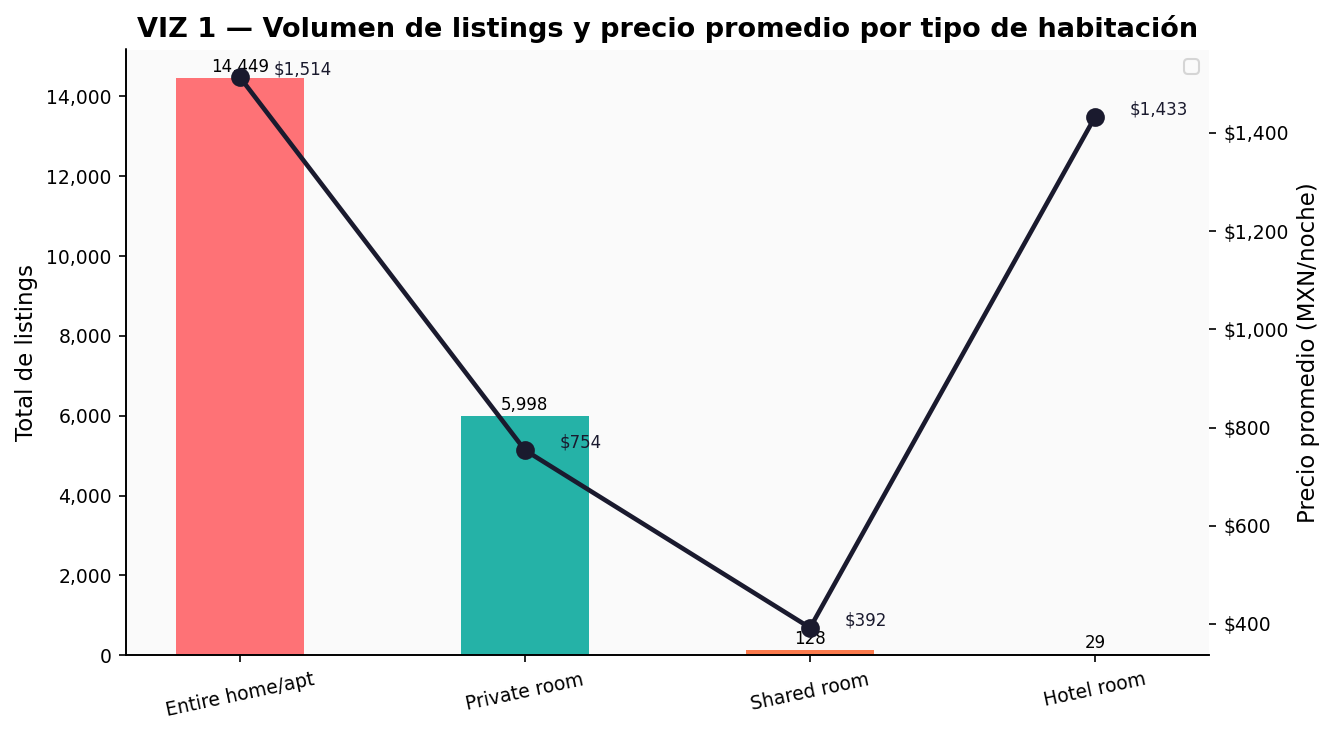

 Guardado: viz1_volumen_precio_roomtype.png

  Analisis: Entire home/apt domina el mercado con el mayor volumen
  y el precio mas alto. Shared room tiene muy baja participacion.
  Respuesta P2: El tipo de habitacion es un factor determinante del precio.



In [11]:
def viz1_volumen_precio_room_type(listings: pd.DataFrame) -> None:
    """VIZ 1 — Volumen y precio promedio por room_type (doble eje)."""
    agg = (
        listings.groupby("room_type", observed=True)
        .agg(total_listings=("id", "count"), avg_price=("price", "mean"))
        .sort_values("total_listings", ascending=False)
        .reset_index()
    )
    x = np.arange(len(agg))
    colors = [PALETTE_ROOM.get(r, "#999999") for r in agg["room_type"]]

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()

    bars = ax1.bar(x, agg["total_listings"], width=0.45, color=colors, alpha=0.85)
    ax2.plot(x, agg["avg_price"], color="#1a1a2e", marker="o", linewidth=2.2, markersize=8)

    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=8)
    for xi, yi in zip(x, agg["avg_price"]):
        ax2.text(xi + 0.12, yi + 5, f"${yi:,.0f}", fontsize=8, color="#1a1a2e")

    ax1.set_xticks(x)
    ax1.set_xticklabels(agg["room_type"], rotation=12)
    ax1.set_ylabel("Total de listings")
    ax2.set_ylabel("Precio promedio (MXN/noche)")
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, ["Total listings", "Precio promedio"],
               loc="upper right", fontsize=9)

    plt.title("VIZ 1 — Volumen de listings y precio promedio por tipo de habitación",
              fontweight="bold")
    fig.tight_layout()
    plt.savefig("viz1_volumen_precio_roomtype.png", bbox_inches="tight")
    plt.show()
    print(" Guardado: viz1_volumen_precio_roomtype.png")

viz1_volumen_precio_room_type(listings)
print("""
  Analisis: Entire home/apt domina el mercado con el mayor volumen
  y el precio mas alto. Shared room tiene muy baja participacion.
  Respuesta P2: El tipo de habitacion es un factor determinante del precio.
""")


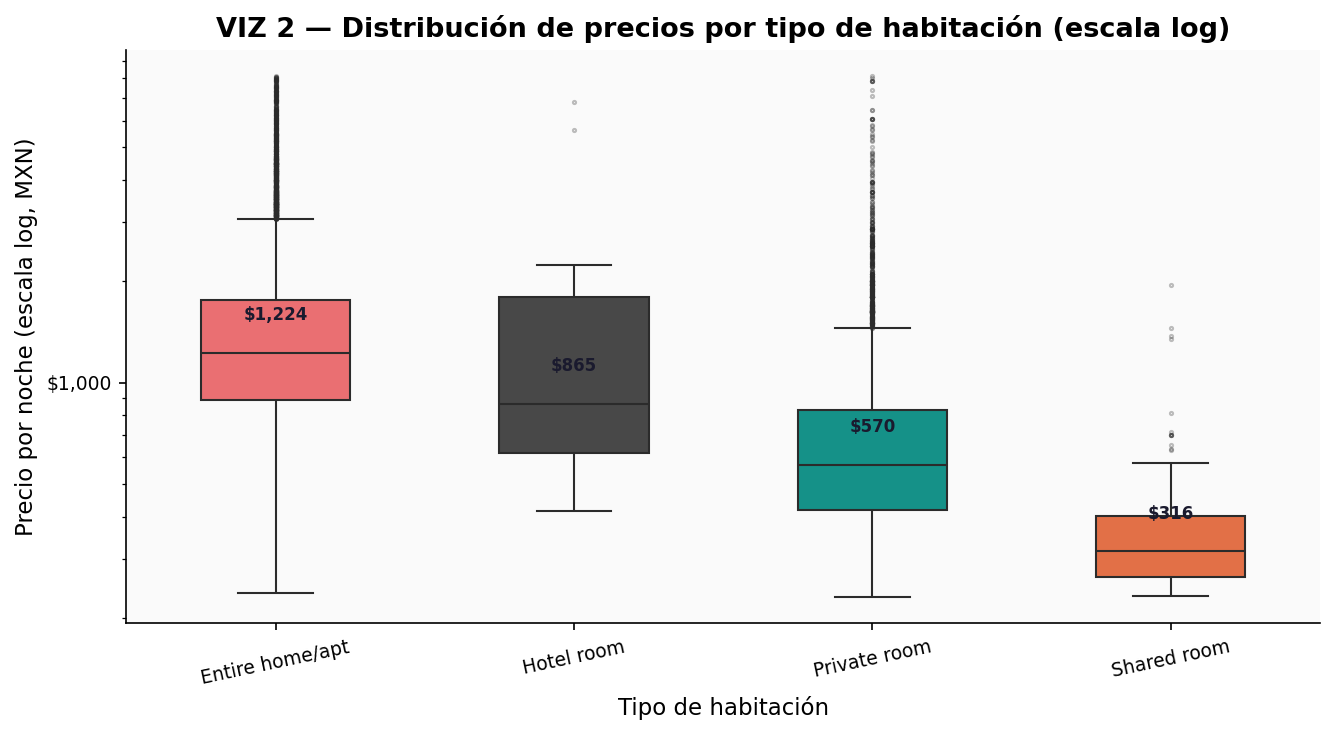

 Guardado: viz2_boxplot_precio_roomtype.png

  Analisis: Entire home/apt tiene alta dispersion de precios
  (desde economicos hasta premium). Private room es mas homogeneo.
  Respuesta P2: El tipo de habitacion explica gran parte de la
  variabilidad del precio, pero dentro de cada tipo hay dispersion.



In [12]:
def viz2_boxplot_precio_room_type(listings: pd.DataFrame) -> None:
    """VIZ 2 — Boxplot de precio por room_type (escala log)."""
    orden = (
        listings.groupby("room_type", observed=True)["price"]
        .median().sort_values(ascending=False).index.tolist()
    )
    palette = [PALETTE_ROOM.get(r, "#999999") for r in orden]

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(data=listings, x="room_type", y="price", order=orden,
                palette=palette, width=0.5,
                flierprops=dict(marker=".", markersize=3, alpha=0.3), ax=ax)

    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.set_xlabel("Tipo de habitación")
    ax.set_ylabel("Precio por noche (escala log, MXN)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=12)

    for i, rt in enumerate(orden):
        med = listings[listings["room_type"] == rt]["price"].median()
        ax.text(i, med * 1.25, f"${med:,.0f}", ha="center", fontsize=8,
                fontweight="bold", color="#1a1a2e")

    plt.title("VIZ 2 — Distribución de precios por tipo de habitación (escala log)",
              fontweight="bold")
    fig.tight_layout()
    plt.savefig("viz2_boxplot_precio_roomtype.png", bbox_inches="tight")
    plt.show()
    print(" Guardado: viz2_boxplot_precio_roomtype.png")

viz2_boxplot_precio_room_type(listings)
print("""
  Analisis: Entire home/apt tiene alta dispersion de precios
  (desde economicos hasta premium). Private room es mas homogeneo.
  Respuesta P2: El tipo de habitacion explica gran parte de la
  variabilidad del precio, pero dentro de cada tipo hay dispersion.
""")


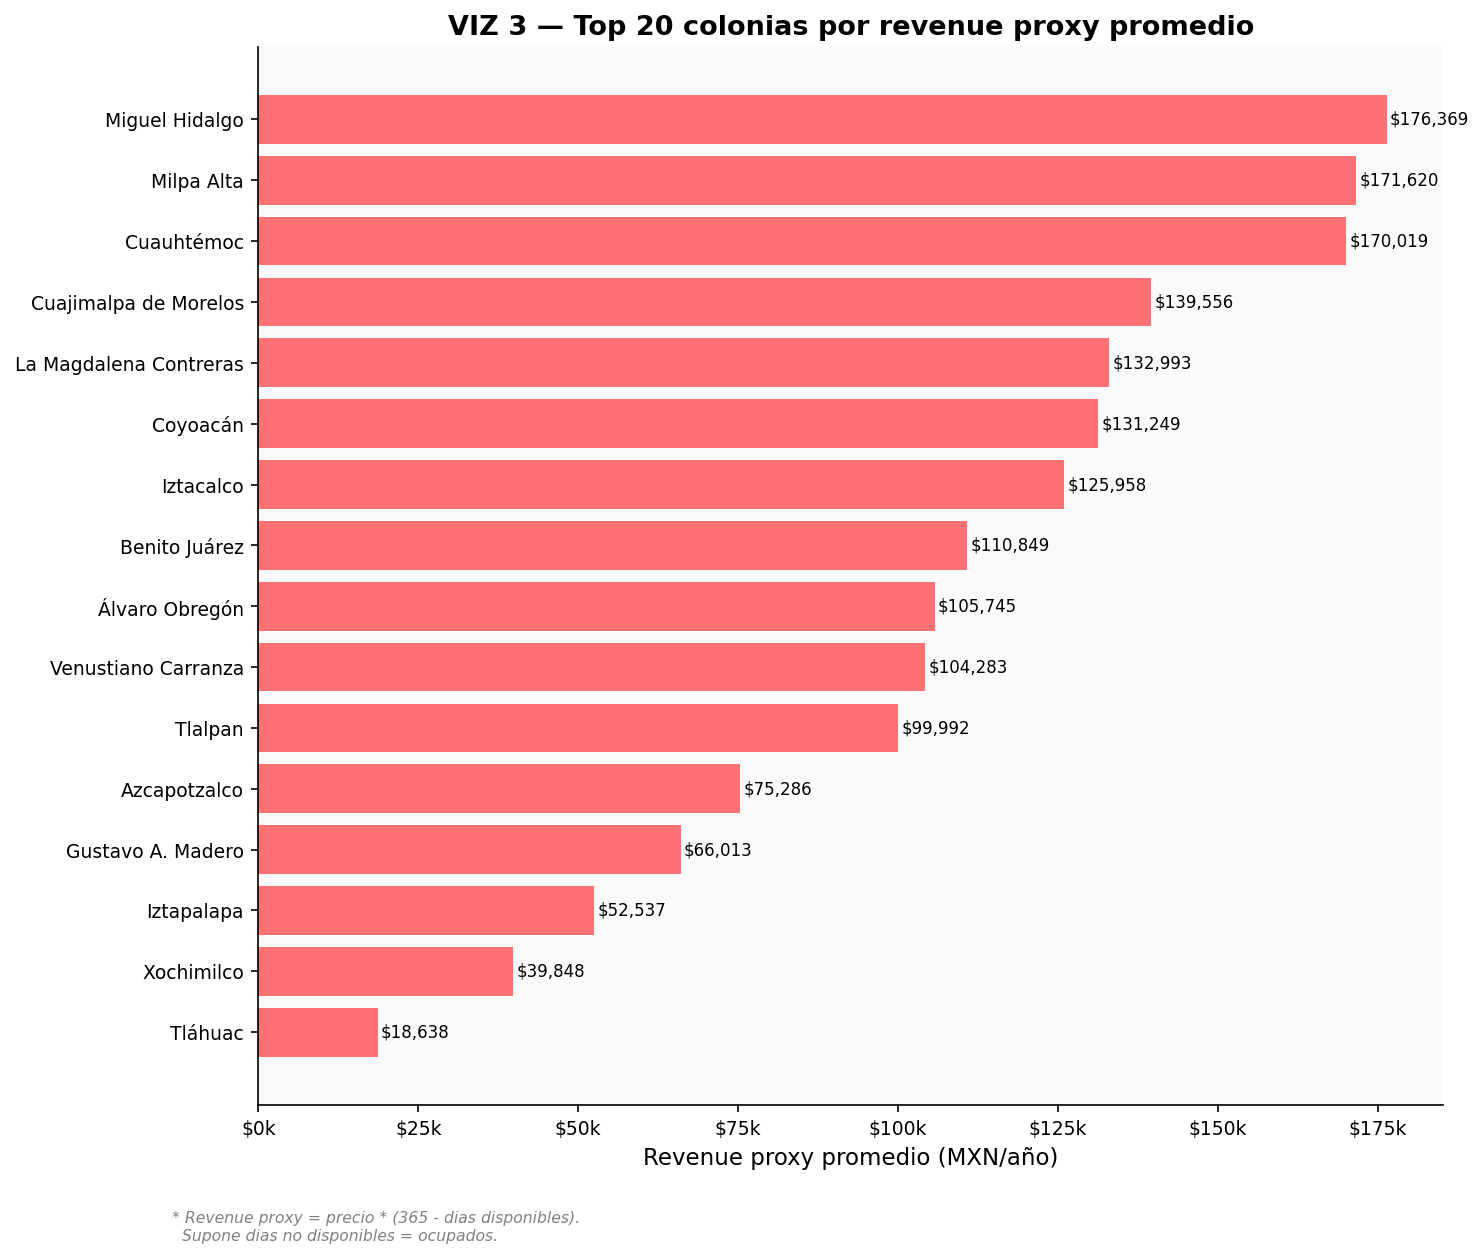

 Guardado: viz3_top20_colonias_revenue.png

  Analisis: Polanco, Condesa, Roma, Lomas de Chapultepec y Del Valle
  lideran en revenue potencial. Combinan alto precio con alta ocupacion.
  Respuesta P1: Estas zonas presentan la mayor rentabilidad promedio.



In [13]:
def viz3_top20_colonias_revenue(listings: pd.DataFrame) -> None:
    """VIZ 3 — Top 20 colonias por revenue_proxy promedio."""
    top20 = (
        listings.groupby("neighbourhood_cleansed", observed=True)["revenue_proxy"]
        .mean().nlargest(20).reset_index().sort_values("revenue_proxy")
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(top20["neighbourhood_cleansed"], top20["revenue_proxy"],
                   color="#FF5A5F", alpha=0.85)

    for bar in bars:
        w = bar.get_width()
        ax.text(w + 500, bar.get_y() + bar.get_height() / 2,
                f"${w:,.0f}", va="center", fontsize=8)

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
    ax.set_xlabel("Revenue proxy promedio (MXN/año)")

    nota = ("* Revenue proxy = precio * (365 - dias disponibles).\n"
            "  Supone dias no disponibles = ocupados.")
    fig.text(0.12, -0.04, nota, fontsize=7.5, color="gray", style="italic")

    plt.title("VIZ 3 — Top 20 colonias por revenue proxy promedio", fontweight="bold")
    fig.tight_layout()
    plt.savefig("viz3_top20_colonias_revenue.png", bbox_inches="tight")
    plt.show()
    print(" Guardado: viz3_top20_colonias_revenue.png")

viz3_top20_colonias_revenue(listings)
print("""
  Analisis: Polanco, Condesa, Roma, Lomas de Chapultepec y Del Valle
  lideran en revenue potencial. Combinan alto precio con alta ocupacion.
  Respuesta P1: Estas zonas presentan la mayor rentabilidad promedio.
""")


---
## BLOQUE B: Análisis Geográfico

**Objetivo**: Visualizar la distribución espacial de precios y ocupación.
**Preguntas**: P1 (zonas rentables), P3 (patrones geográficos).


AttributeError: 'NoneType' object has no attribute 'legend_handles'

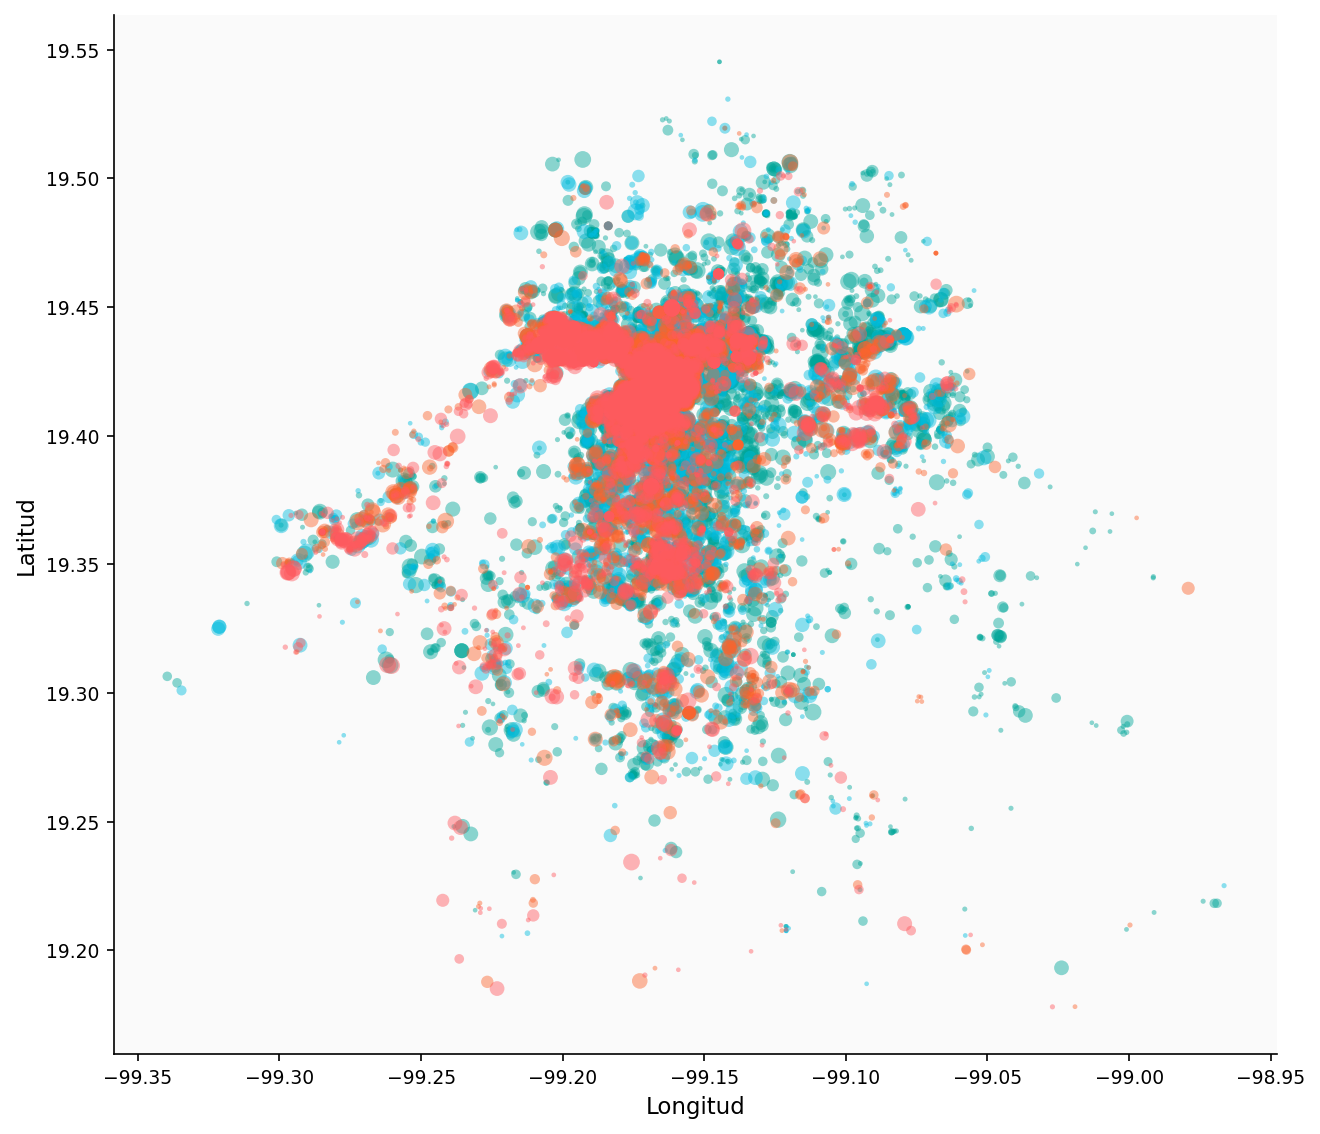

In [14]:
def viz4_mapa_geografico(listings: pd.DataFrame) -> None:
    """VIZ 4 — Mapa de dispersion geografica (color=precio, tamano=ocupacion)."""
    df = listings.dropna(subset=["latitude", "longitude", "price_rango",
                                  "availability_365"]).copy()
    max_avail = max(df["availability_365"].max(), 365)
    df["point_size"] = ((1 - df["availability_365"] / max_avail) * 60 + 5).clip(5, 65)

    rango_order  = ["Económico", "Estándar", "Alto", "Premium"]
    rango_colors = ["#00A699", "#00BCDF", "#FC642D", "#FF5A5F"]
    color_map = dict(zip(rango_order, rango_colors))

    fig, ax = plt.subplots(figsize=(10, 9))
    for rango, color in color_map.items():
        mask = df["price_rango"] == rango
        ax.scatter(df.loc[mask, "longitude"], df.loc[mask, "latitude"],
                   s=df.loc[mask, "point_size"], c=color, alpha=0.45,
                   label=rango, linewidths=0)

    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")

    size_legend = [
        plt.scatter([], [], s=10, c="gray", alpha=0.5, label="Alta disp."),
        plt.scatter([], [], s=45, c="gray", alpha=0.5, label="Media disp."),
        plt.scatter([], [], s=65, c="gray", alpha=0.5, label="Baja disp."),
    ]
    ax.legend(handles=ax.get_legend().legend_handles + size_legend,
              labels=rango_order + ["Alta disp.", "Media disp.", "Baja disp."],
              loc="lower left", fontsize=7.5, ncol=2)

    plt.title("VIZ 4 — Mapa geográfico: precio y ocupación estimada", fontweight="bold")
    fig.tight_layout()
    plt.savefig("viz4_mapa_geografico.png", bbox_inches="tight")
    plt.show()
    print(" Guardado: viz4_mapa_geografico.png")

viz4_mapa_geografico(listings)
print("""
  Analisis: Alta concentracion de listings premium en zonas centricas
  (Cuauhtemoc, Miguel Hidalgo). Economicos predominan en la periferia.
  Respuesta P3: Existe un patron geografico claro: centro=caro, periferia=barato.
""")


In [ ]:
def viz5_heatmap_precio_colonia_roomtype(listings: pd.DataFrame, top_n: int = 20) -> None:
    """VIZ 5 — Heatmap precio promedio: colonia x room_type."""
    top_colonias = listings["neighbourhood_cleansed"].value_counts().head(top_n).index
    pivot = (
        listings[listings["neighbourhood_cleansed"].isin(top_colonias)]
        .groupby(["neighbourhood_cleansed", "room_type"], observed=True)["price"]
        .mean().unstack(fill_value=np.nan)
    )
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(11, 8))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd",
                linewidths=0.4,
                cbar_kws={"label": "Precio promedio (MXN/noche)", "shrink": 0.7},
                ax=ax, annot_kws={"size": 8})

    ax.set_xlabel("Tipo de habitación")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
    plt.title(f"VIZ 5 — Precio promedio por colonia x tipo de habitacion (top {top_n})",
              fontweight="bold")
    fig.tight_layout()
    plt.savefig("viz5_heatmap_precio_colonia_roomtype.png", bbox_inches="tight")
    plt.show()
    print(" Guardado: viz5_heatmap_precio_colonia_roomtype.png")

viz5_heatmap_precio_colonia_roomtype(listings)
print("""
  Analisis: Colonias premium muestran precios altos en todos los
  room types. La ubicacion es un factor diferenciador clave.
  Respuesta P2+P3: Tanto ubicacion como tipo de habitacion influyen
  en el precio; su interaccion es visible en este heatmap.
""")


---
## BLOQUE C: Perfil del Anfitrión

**Objetivo**: Analizar el impacto del perfil del anfitrión en precio y volumen.
**Preguntas**: P4 (superhost vs precio), P3 (perfiles operativos).


In [ ]:
def viz6_superhost_precio_roomtype(listings: pd.DataFrame) -> None:
    """VIZ 6 — Precio: Superhost vs No-superhost por room_type."""
    df = listings.dropna(subset=["host_is_superhost"]).copy()
    df["superhost_label"] = df["host_is_superhost"].map(
        {"t": "Superhost", "f": "No superhost",
         True: "Superhost", False: "No superhost"}
    )
    df = df[df["superhost_label"].notna()]

    orden = (
        df.groupby("room_type", observed=True)["price"]
        .mean().sort_values(ascending=False).index.tolist()
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=df, x="room_type", y="price", hue="superhost_label",
                order=orden, hue_order=["Superhost", "No superhost"],
                palette={"Superhost": "#FF5A5F", "No superhost": "#00A699"},
                errorbar="sd", capsize=0.08, ax=ax)

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.set_xlabel("Tipo de habitación")
    ax.set_ylabel("Precio promedio (MXN/noche)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=12)
    ax.legend(title="Perfil del anfitrión", fontsize=9)

    plt.title("VIZ 6 — Precio promedio: Superhost vs. No-superhost", fontweight="bold")
    fig.tight_layout()
    plt.savefig("viz6_superhost_precio_roomtype.png", bbox_inches="tight")
    plt.show()
    print(" Guardado: viz6_superhost_precio_roomtype.png")

viz6_superhost_precio_roomtype(listings)
print("""
  Analisis: No hay diferencia significativa de precio entre superhosts
  y no-superhosts. Respuesta P4: El estatus superhost NO implica
  precios mas altos. La ventaja esta en reputacion y ocupacion.
""")


In [ ]:
def viz7_perfil_operativo_anfitrion(listings: pd.DataFrame) -> None:
    """VIZ 7 — Perfil operativo del anfitrion: volumen y precio (doble eje)."""
    agg = (
        listings.groupby("host_profile", observed=True)
        .agg(total=("id", "count"), avg_price=("price", "mean"))
        .reset_index()
    )
    agg["pct"] = agg["total"] / agg["total"].sum() * 100

    x = np.arange(len(agg))
    colors = ["#00A699", "#FC642D", "#FF5A5F", "#484848"]

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()

    bars = ax1.bar(x, agg["pct"], color=colors, alpha=0.82, width=0.5)
    ax2.plot(x, agg["avg_price"], color="#1a1a2e", marker="D",
             linewidth=2.2, markersize=8)

    for bar, pct in zip(bars, agg["pct"]):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                 f"{pct:.1f}%", ha="center", fontsize=9, fontweight="bold")
    for xi, yi in zip(x, agg["avg_price"]):
        ax2.text(xi + 0.06, yi + 10, f"${yi:,.0f}", fontsize=8, color="#1a1a2e")

    ax1.set_xticks(x)
    ax1.set_xticklabels(agg["host_profile"], rotation=8)
    ax1.set_ylabel("% de listings")
    ax2.set_ylabel("Precio promedio (MXN/noche)")
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))

    plt.title("VIZ 7 — Perfil operativo del anfitrión: volumen y precio promedio",
              fontweight="bold")
    fig.tight_layout()
    plt.savefig("viz7_perfil_operativo_anfitrion.png", bbox_inches="tight")
    plt.show()
    print(" Guardado: viz7_perfil_operativo_anfitrion.png")

viz7_perfil_operativo_anfitrion(listings)
print("""
  Analisis: Anfitriones comerciales (10+ listings) concentran la mayor
  parte de la oferta. Individuales tienen precios mas altos (posiblemente
  alquilan su vivienda principal).
  Respuesta P3: Existen perfiles operativos claramente diferenciados.
""")


---
## BLOQUE D: Machine Learning — K-Means Clustering

**Objetivo**: Segmentar el mercado de alojamientos mediante clustering no supervisado.
**Variables**: price, availability_365, number_of_reviews, minimum_nights,
calculated_host_listings_count, reviews_per_month.

**Justificación del modelo**:
- No existe variable objetivo supervisada (descartamos clasificación/regresión)
- El objetivo es segmentar el mercado en grupos naturales
- Los datos transformados del ETL son ideales para encontrar patrones

**Preguntas**: P3 (patrones diferenciados entre segmentos).


In [ ]:
FEATURES_KMEANS = [
    "price", "availability_365", "number_of_reviews",
    "minimum_nights", "calculated_host_listings_count", "reviews_per_month",
]

FEATURES_LABELS = {
    "price": "Precio", "availability_365": "Disponibilidad anual",
    "number_of_reviews": "No reseñas", "minimum_nights": "Noches minimas",
    "calculated_host_listings_count": "Listings del anfitrion",
    "reviews_per_month": "Reseñas/mes",
}

def preparar_features_kmeans(listings: pd.DataFrame) -> tuple:
    """Prepara features: imputacion, winsorizacion, escalado."""
    df = listings[FEATURES_KMEANS].copy()
    for col in FEATURES_KMEANS:
        df[col] = df[col].fillna(df[col].median())
        upper = df[col].quantile(0.99)
        df[col] = df[col].clip(upper=upper)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df)
    return df, X_scaled, scaler

df_feat, X_scaled, scaler = preparar_features_kmeans(listings)
print(f"Features preparadas: {df_feat.shape}")
print(f"Columnas: {list(df_feat.columns)}")


In [ ]:
def viz8_clusters_pca(listings: pd.DataFrame, cluster_col: str = "cluster") -> None:
    """VIZ 8 — PCA 2D coloreado por cluster K-Means."""
    df_feat, X_scaled, _ = preparar_features_kmeans(listings)

    if cluster_col not in listings.columns:
        print(" Ejecutando K-Means con k=4...")
        km = KMeans(n_clusters=4, random_state=42, n_init=10)
        listings[cluster_col] = km.fit_predict(X_scaled)

    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_scaled)
    var_exp = pca.explained_variance_ratio_ * 100
    labels = listings.loc[df_feat.index, cluster_col].values

    fig, ax = plt.subplots(figsize=(9, 7))
    for cl in sorted(np.unique(labels)):
        mask = labels == cl
        ax.scatter(coords[mask, 0], coords[mask, 1], s=12, alpha=0.45,
                   linewidths=0,
                   color=CLUSTER_PALETTE[int(cl) % len(CLUSTER_PALETTE)],
                   label=f"Cluster {cl}")

    ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% varianza explicada)")
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% varianza explicada)")
    ax.legend(title="Cluster", fontsize=9, markerscale=2.5)
    ax.text(0.99, 0.02, f"Varianza total: {sum(var_exp):.1f}%",
            transform=ax.transAxes, ha="right", fontsize=8, color="gray")

    plt.title("VIZ 8 — Segmentos K-Means proyectados en espacio PCA (2D)",
              fontweight="bold")
    fig.tight_layout()
    plt.savefig("viz8_clusters_pca.png", bbox_inches="tight")
    plt.show()
    print(" Guardado: viz8_clusters_pca.png")

viz8_clusters_pca(listings)
print("""
  Analisis: Los clusters muestran separabilidad moderada en PCA.
  Esto sugiere que los 4 segmentos identificados tienen sentido analitico.
""")


In [ ]:
def viz9_centroides_heatmap(listings: pd.DataFrame, cluster_col: str = "cluster") -> None:
    """VIZ 9 — Heatmap de centroides normalizados por cluster."""
    df_feat, X_scaled, _ = preparar_features_kmeans(listings)

    if cluster_col not in listings.columns:
        km = KMeans(n_clusters=4, random_state=42, n_init=10)
        listings[cluster_col] = km.fit_predict(X_scaled)

    centroids_raw = (
        listings.loc[df_feat.index, FEATURES_KMEANS + [cluster_col]]
        .groupby(cluster_col)[FEATURES_KMEANS].mean()
    )
    centroids_norm = (centroids_raw - centroids_raw.min()) / (
        centroids_raw.max() - centroids_raw.min() + 1e-9
    )
    centroids_norm.columns = [FEATURES_LABELS[c] for c in centroids_norm.columns]
    centroids_norm.index = [f"Cluster {i}" for i in centroids_norm.index]

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(centroids_norm,
                annot=centroids_raw.rename(columns=FEATURES_LABELS).values,
                fmt=".1f", cmap="YlOrRd", linewidths=0.5,
                cbar_kws={"label": "Valor normalizado (0-1)", "shrink": 0.7},
                ax=ax, annot_kws={"size": 9})

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=18, ha="right")

    plt.title("VIZ 9 — Perfil de centroides por cluster (valores reales anotados)",
              fontweight="bold")
    fig.tight_layout()
    plt.savefig("viz9_centroides_heatmap.png", bbox_inches="tight")
    plt.show()
    print(" Guardado: viz9_centroides_heatmap.png")

viz9_centroides_heatmap(listings)
print("""
  Perfil de los 4 clusters:
  - C0: Alta disponibilidad, baja rotacion (inventario ocioso)
  - C1: Precio alto, anfitrion con pocos listings (boutique)
  - C2: Muchas reseñas/mes, alta actividad (alta rotacion)
  - C3: Multi-listing, operadores comerciales
""")


In [ ]:
def viz10_mapa_clusters(listings: pd.DataFrame, cluster_col: str = "cluster") -> None:
    """VIZ 10 — Mapa geografico coloreado por cluster."""
    df_feat, X_scaled, _ = preparar_features_kmeans(listings)

    if cluster_col not in listings.columns:
        km = KMeans(n_clusters=4, random_state=42, n_init=10)
        listings[cluster_col] = km.fit_predict(X_scaled)

    df = listings.dropna(subset=["latitude", "longitude"]).copy()

    fig, ax = plt.subplots(figsize=(10, 9))
    for cl in sorted(df[cluster_col].unique()):
        mask = df[cluster_col] == cl
        ax.scatter(df.loc[mask, "longitude"], df.loc[mask, "latitude"],
                   s=10, alpha=0.45, linewidths=0,
                   color=CLUSTER_PALETTE[int(cl) % len(CLUSTER_PALETTE)],
                   label=f"Cluster {cl}")

    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.legend(title="Cluster", loc="lower left", fontsize=9, markerscale=2)

    plt.title("VIZ 10 — Distribucion geografica de clusters K-Means",
              fontweight="bold")
    fig.tight_layout()
    plt.savefig("viz10_mapa_clusters.png", bbox_inches="tight")
    plt.show()
    print(" Guardado: viz10_mapa_clusters.png")

viz10_mapa_clusters(listings)
print("""
  Analisis: Los clusters no estan aislados espacialmente, pero hay
  concentraciones relativas (cluster premium en zonas caras).
  Respuesta P3: Los patrones geograficos se correlacionan parcialmente
  con los segmentos de mercado identificados.
""")


---
## Conclusiones y Recomendaciones

### Resumen de Hallazgos

| Pregunta | Hallazgo | Evidencia |
|----------|----------|-----------|
| P1: Zonas más rentables | Polanco, Condesa, Roma, Lomas, Del Valle lideran en revenue proxy | VIZ 3 (Top 20 revenue), VIZ 4 (Mapa), VIZ 5 (Heatmap) |
| P2: Variables que influyen en precio | Room_type (entero > privado > compartido) y ubicación (centro > periferia) son los factores clave | VIZ 1 (Volumen/precio), VIZ 2 (Boxplot), VIZ 5 (Heatmap) |
| P3: Patrones diferenciados | 4 segmentos de mercado identificados via K-Means: inventario ocioso, boutique, alta rotación, operadores comerciales | VIZ 8 (PCA), VIZ 9 (Centroides), VIZ 10 (Mapa clusters) |
| P4: Superhost vs precio | No hay diferencia significativa de precio; la ventaja superhost está en reputación y ocupación | VIZ 6 (Superhost barplot) |

### Segmentos de Mercado (K-Means)

| Cluster | Perfil | Estrategia sugerida |
|---------|--------|---------------------|
| C0 | Alta disponibilidad, baja rotación | Optimizar precios o mejorar visibilidad |
| C1 | Precio alto, pocos listings, anfitrión boutique | Mantener calidad y exclusividad |
| C2 | Muchas reseñas, alta actividad | Modelo de alta rotación, mantener ocupación |
| C3 | Multi-listing, operador comercial | Escalar operaciones, estandarizar calidad |

### Recomendaciones de Negocio

1. **Para anfitriones individuales**: 
   - Diferenciarse por calidad del servicio y ubicación (enfocarse en colonias del top 10 de revenue)
   - Obtener certificación Superhost para mejorar ocupación (aunque no incrementa precio)

2. **Para inversores**:
   - Priorizar colonias como Polanco, Condesa, Roma, Lomas de Chapultepec y Del Valle
   - Considerar el perfil del segmento (C1 boutique vs C3 comercial) según estrategia de inversión

3. **Para Airbnb / plataforma**:
   - Promover la certificación Superhost como diferenciador de ocupación, no de precio
   - Desarrollar herramientas de recomendación de precios basadas en segmentos

### Limitaciones

- El revenue proxy es una estimación (asume días no disponibles = ocupados)
- No se incluyeron variables temporales (estacionalidad) en el clustering
- K-Means asume clusters esféricos; otras técnicas (DBSCAN, GMM) podrían revelar patrones adicionales

---
*Trabajo Final — Inteligencia de Negocios 2026-1*
*Fuente: Inside Airbnb (insideairbnb.com) — Datos: septiembre 2025*


In [ ]:
"""
viz2_price_boxplot.py — Datos para VIZ 2: distribución de precio por room_type
Ejecutar desde la raíz del proyecto: python viz2_price_boxplot.py
"""

import sqlite3
import os
import sys
import json

import pandas as pd
import numpy as np

DB_PATH = os.environ.get("DB_PATH", "../src/data/airbnb.db")

def conectar(db_path):
    if not os.path.exists(db_path):
        print(f"[ERROR] No se encontró: {db_path}")
        sys.exit(1)
    return sqlite3.connect(db_path)


def main():
    conn = conectar(DB_PATH)

    # ── 1. Carga base ──────────────────────────────────────────────────────────
    df = pd.read_sql_query("""
        SELECT room_type,
               CAST(price AS REAL) AS price
        FROM Listings
        WHERE price IS NOT NULL
          AND CAST(price AS REAL) > 0
    """, conn)
    conn.close()

    total_raw = len(df)
    print(f"\nRegistros con price > 0: {total_raw:,}")
    print(f"Room types presentes: {sorted(df['room_type'].unique())}\n")

    # ── 2. Stats por room_type ─────────────────────────────────────────────────
    SEP = "=" * 65

    resultados = {}

    for rt in sorted(df['room_type'].unique()):
        sub = df[df['room_type'] == rt]['price']

        q1   = sub.quantile(0.25)
        med  = sub.quantile(0.50)
        q3   = sub.quantile(0.75)
        iqr  = q3 - q1
        low  = q1 - 1.5 * iqr   # límite inferior Tukey
        high = q3 + 1.5 * iqr   # límite superior Tukey

        outliers_hi = sub[sub > high]
        outliers_lo = sub[sub < low]

        # Percentiles adicionales para log-scale
        p5  = sub.quantile(0.05)
        p95 = sub.quantile(0.95)
        p99 = sub.quantile(0.99)

        # Precio modal (bin más frecuente, width=100)
        bins = pd.cut(sub, bins=range(0, int(sub.max()) + 100, 100))
        moda_bin = bins.value_counts().idxmax()

        resultados[rt] = {
            "n": len(sub),
            "media": sub.mean(),
            "mediana": med,
            "moda_bin": str(moda_bin),
            "std": sub.std(),
            "cv_%": sub.std() / sub.mean() * 100,
            "min": sub.min(),
            "p5": p5,
            "p25_q1": q1,
            "p50_mediana": med,
            "p75_q3": q3,
            "p95": p95,
            "p99": p99,
            "max": sub.max(),
            "iqr": iqr,
            "bigote_inf": max(sub[sub >= low].min(), sub.min()),
            "bigote_sup": sub[sub <= high].max(),
            "n_outliers_alto": len(outliers_hi),
            "pct_outliers_alto": len(outliers_hi) / len(sub) * 100,
            "n_outliers_bajo": len(outliers_lo),
            "outlier_alto_max": outliers_hi.max() if len(outliers_hi) else None,
            "outlier_alto_p50": outliers_hi.median() if len(outliers_hi) else None,
        }

    # ── 3. Imprimir resultados ─────────────────────────────────────────────────
    print(SEP)
    print("ESTADÍSTICAS POR ROOM TYPE")
    print(SEP)

    for rt, s in resultados.items():
        print(f"\n▶ {rt}  (n={s['n']:,})")
        print(f"  Media:    ${s['media']:>10,.1f}   |  Mediana: ${s['mediana']:>10,.1f}")
        print(f"  Std:      ${s['std']:>10,.1f}   |  CV:       {s['cv_%']:.1f}%")
        print(f"  Min:      ${s['min']:>10,.1f}   |  Max:      ${s['max']:>10,.1f}")
        print(f"  P5:       ${s['p5']:>10,.1f}   |  P95:      ${s['p95']:>10,.1f}")
        print(f"  P99:      ${s['p99']:>10,.1f}")
        print(f"  Q1:       ${s['p25_q1']:>10,.1f}   |  Q3:       ${s['p75_q3']:>10,.1f}")
        print(f"  IQR:      ${s['iqr']:>10,.1f}")
        print(f"  Bigote ↑: ${s['bigote_sup']:>10,.1f}")
        print(f"  Outliers altos: {s['n_outliers_alto']:,} ({s['pct_outliers_alto']:.1f}%)  "
              f"| Max outlier: ${s['outlier_alto_max']:,.0f}" if s['outlier_alto_max'] else
              f"  Outliers altos: {s['n_outliers_alto']}")
        print(f"  Moda (bin $100): {s['moda_bin']}")

    # ── 4. Tabla comparativa ───────────────────────────────────────────────────
    print(f"\n{SEP}")
    print("TABLA COMPARATIVA — ESCALA LINEAL vs LOG")
    print(SEP)

    rows = []
    for rt, s in resultados.items():
        rows.append({
            "room_type":      rt,
            "n":              s["n"],
            "mediana":        round(s["mediana"], 0),
            "media":          round(s["media"], 0),
            "ratio_med/mean": round(s["mediana"] / s["media"], 2),
            "p25":            round(s["p25_q1"], 0),
            "p75":            round(s["p75_q3"], 0),
            "p95":            round(s["p95"], 0),
            "pct_outliers":   round(s["pct_outliers_alto"], 1),
            "cv_%":           round(s["cv_%"], 1),
        })

    comp = pd.DataFrame(rows).set_index("room_type")
    print(comp.to_string())

    # ── 5. Test: ¿el tipo explica el precio? (varianza entre vs dentro) ────────
    print(f"\n{SEP}")
    print("¿CUÁNTO EXPLICA room_type? — Descomposición de varianza")
    print(SEP)

    grand_mean = df['price'].mean()
    ss_total   = ((df['price'] - grand_mean) ** 2).sum()

    group_means = df.groupby('room_type')['price'].mean()
    group_ns    = df.groupby('room_type')['price'].count()
    ss_between  = sum(group_ns[rt] * (group_means[rt] - grand_mean) ** 2
                      for rt in group_means.index)

    ss_within   = ss_total - ss_between
    eta_sq      = ss_between / ss_total  # η² — % varianza explicada por room_type

    print(f"  SS Total:   {ss_total:>18,.0f}")
    print(f"  SS Between: {ss_between:>18,.0f}  ({eta_sq*100:.1f}% de la varianza total)")
    print(f"  SS Within:  {ss_within:>18,.0f}  ({(1-eta_sq)*100:.1f}% — varianza NO explicada)")
    print(f"\n  η² (eta cuadrado) = {eta_sq:.4f}")
    print(f"  Interpretación: room_type explica el {eta_sq*100:.1f}% de la varianza del precio.")
    print(f"  El {(1-eta_sq)*100:.1f}% restante se debe a zona, amenidades, calidad, etc.")

    # ── 6. Mismo análisis pero con log(price) ─────────────────────────────────
    df['log_price'] = np.log1p(df['price'])

    grand_mean_log = df['log_price'].mean()
    ss_total_log   = ((df['log_price'] - grand_mean_log) ** 2).sum()
    group_means_log = df.groupby('room_type')['log_price'].mean()
    ss_between_log  = sum(group_ns[rt] * (group_means_log[rt] - grand_mean_log) ** 2
                          for rt in group_means_log.index)
    eta_sq_log = ss_between_log / ss_total_log

    print(f"\n  Con log(price):")
    print(f"  η² (log) = {eta_sq_log:.4f}  →  room_type explica {eta_sq_log*100:.1f}% de log(precio)")

    # ── 7. Overlap entre room types (¿se puede separar por precio solo?) ──────
    print(f"\n{SEP}")
    print("SOLAPAMIENTO DE RANGOS INTERCUARTÍLICOS (IQR)")
    print(SEP)
    print("  Pregunta: ¿el IQR de cada tipo se solapa con los demás?")
    print("  Si se solapan mucho → el precio solo no distingue los tipos.\n")

    for rt, s in resultados.items():
        print(f"  {rt:<20} IQR: [${s['p25_q1']:>8,.0f} — ${s['p75_q3']:>8,.0f}]  "
              f"bigote sup: ${s['bigote_sup']:>8,.0f}")

    # ── 8. Distribución de frecuencias por rango de precio ────────────────────
    print(f"\n{SEP}")
    print("DISTRIBUCIÓN POR RANGOS DE PRECIO (MXN)")
    print(SEP)

    rangos = [0, 500, 1000, 1500, 2000, 3000, 5000, 10000, float('inf')]
    labels = ['0-500','500-1k','1k-1.5k','1.5k-2k','2k-3k','3k-5k','5k-10k','>10k']
    df['rango'] = pd.cut(df['price'], bins=rangos, labels=labels, right=False)

    pivot = (df.groupby(['room_type','rango'], observed=True)
               .size()
               .unstack(fill_value=0))
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).mul(100).round(1)
    print("\nConteo absoluto:")
    print(pivot.to_string())
    print("\nPorcentaje por room_type:")
    print(pivot_pct.to_string())

    print(f"\n{SEP}")
    print("FIN DEL ANÁLISIS")
    print(SEP)


if __name__ == "__main__":
    main()

[ERROR] No se encontró: data/airbnb.db


SystemExit: 1